Task I – Part 1: Five-Qubit Quantum Circuit
============================================
Implements the following sequence of operations:

    a) Hadamard gate on every qubit
    b) CNOT on pairs (0,1), (1,2), (2,3), (3,4)
    c) SWAP between qubits 0 and 4
    d) X-rotation by pi/2 on qubit 2
    e) Circuit diagram saved to circuit1.png

In [1]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 108.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 90.7 MB/s eta 0:00:00


In [2]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

Circuit 1 – Statevector (first 8 amplitudes shown)
  |00000> : 0.125000-0.125000j
  |00001> : 0.125000-0.125000j
  |00010> : 0.125000-0.125000j
  |00011> : 0.125000-0.125000j
  |00100> : 0.125000-0.125000j
  |00101> : 0.125000-0.125000j
  |00110> : 0.125000-0.125000j
  |00111> : 0.125000-0.125000j


/tmp/ipykernel_13876/3480608347.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


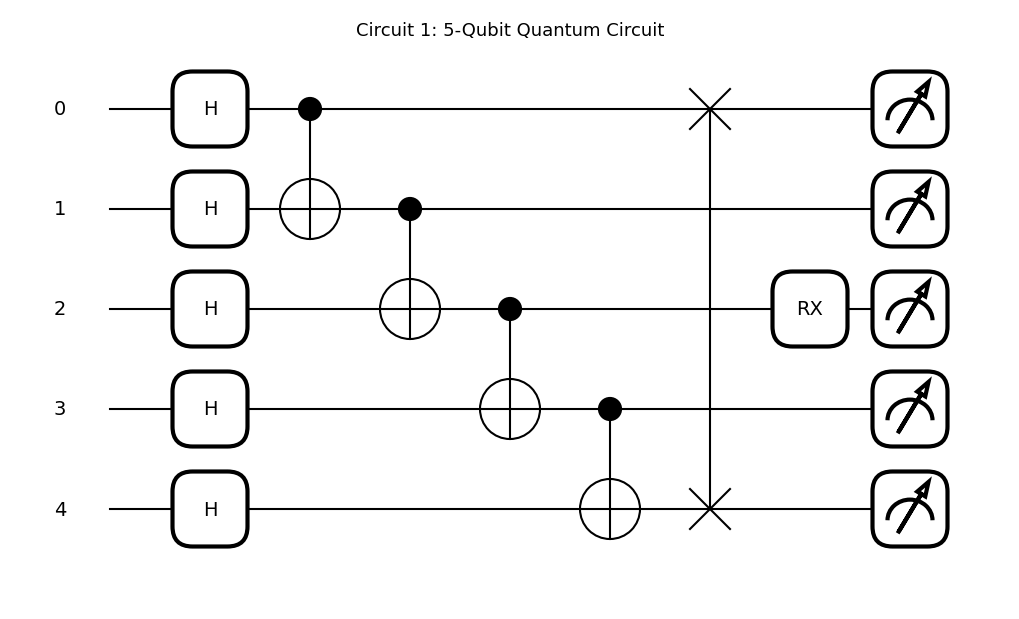


Text circuit diagram:
0: ──H─╭●──────────╭SWAP───────────┤  State
1: ──H─╰X─╭●───────│───────────────┤  State
2: ──H────╰X─╭●────│──────RX(1.57)─┤  State
3: ──H───────╰X─╭●─│───────────────┤  State
4: ──H──────────╰X─╰SWAP───────────┤  State


In [4]:
# ---------------------------------------------------------------------------
# Simulator backend — statevector simulation on the default PennyLane device
# ---------------------------------------------------------------------------
N_QUBITS = 5
dev = qml.device("default.qubit", wires=N_QUBITS)


# ---------------------------------------------------------------------------
# Circuit definition
# ---------------------------------------------------------------------------
@qml.qnode(dev)
def circuit1():
    # Place each qubit into an equal superposition of |0⟩ and |1⟩
    for q in range(N_QUBITS):
        qml.Hadamard(wires=q)

    # Entangle adjacent qubits through a linear CNOT chain, propagating
    # correlations from qubit 0 through to qubit 4
    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[1, 2])
    qml.CNOT(wires=[2, 3])
    qml.CNOT(wires=[3, 4])

    # Exchange the quantum states of the first and last qubits
    qml.SWAP(wires=[0, 4])

    # Apply a rotation of π/2 about the X-axis on qubit 2, introducing a
    # relative phase of e^{-iπ/4} between the |0⟩ and |1⟩ components
    qml.RX(np.pi / 2, wires=2)

    return qml.state()


# ---------------------------------------------------------------------------
# Entry point — executes the circuit and exports visualisations
# ---------------------------------------------------------------------------
def main():
    state = circuit1()

    print("Circuit 1 – Statevector (first 8 amplitudes shown)")
    print("=" * 60)
    for idx, amp in enumerate(state[:8]):
        print(f"  |{idx:05b}> : {amp:.6f}")

    fig, ax = qml.draw_mpl(circuit1)()
    fig.suptitle("Circuit 1: 5-Qubit Quantum Circuit", fontsize=13)
    fig.tight_layout()
    fig.savefig("circuit1.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    # Print the ASCII wire diagram for quick terminal inspection
    print("\nText circuit diagram:")
    print(qml.draw(circuit1)())


if __name__ == "__main__":
    main()

Task I – Part 2: SWAP Test Circuit
====================================
State preparation
-----------------
  - q0 : Hadamard gate             → (|0> + |1>) / sqrt(2)
  
  - q1 : RX(pi/3)                  → cos(pi/6)|0> − i·sin(pi/6)|1>
  
  - q2 : Hadamard gate             → (|0> + |1>) / sqrt(2)
  
  - q3 : Hadamard gate             → (|0> + |1>) / sqrt(2)

SWAP test compares |ψ> = |q0 q1> against |φ> = |q2 q3>
---------------------------------------------------------
An ancilla qubit (q4) is used. The procedure is:
  1. H on ancilla
  2. Controlled-SWAP(ancilla, q0, q2)  – swaps first qubits of each state
  3. Controlled-SWAP(ancilla, q1, q3)  – swaps second qubits of each state
  4. H on ancilla
  5. Measure ancilla in the computational basis

Outcome interpretation:
  
  - P(ancilla=0) = (1 + |<ψ|φ>|²) / 2
  
  - |<ψ|φ>|²    = 2·P(ancilla=0) − 1

Circuit 2 – SWAP Test Results
  P(ancilla = |0⟩) = 0.750000
  P(ancilla = |1⟩) = 0.250000

  |⟨ψ|φ⟩|² (simulated)  = 0.500000
  |⟨ψ|φ⟩|² (analytical) = 0.500000

  Verdict: states have a squared overlap of 0.5000


/tmp/ipykernel_13876/1974876446.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


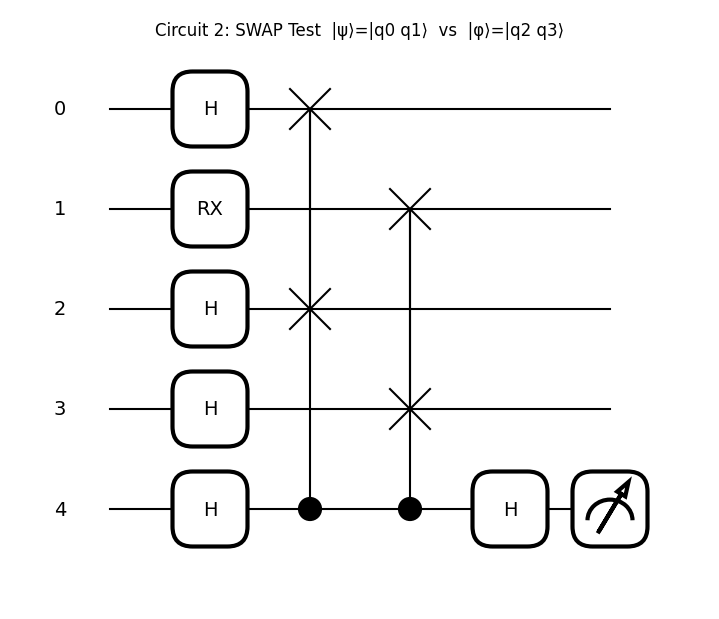

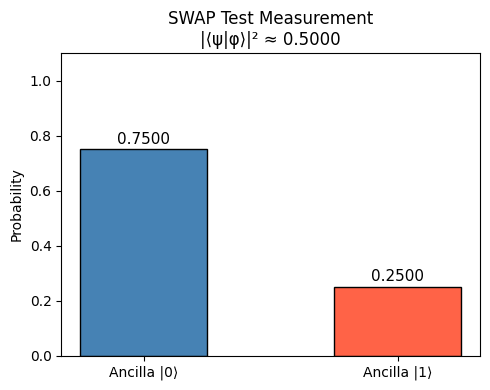


Text circuit diagram:
0: ──H────────╭SWAP──────────┤       
1: ──RX(1.05)─│─────╭SWAP────┤       
2: ──H────────├SWAP─│────────┤       
3: ──H────────│─────├SWAP────┤       
4: ──H────────╰●────╰●─────H─┤  Probs


In [7]:
# ---------------------------------------------------------------------------
# Circuit definition
# ---------------------------------------------------------------------------
@qml.qnode(dev)
def circuit2():
    # State preparation

    # Prepare |ψ⟩ = |q0 q1⟩
    qml.Hadamard(wires=0)          # q0 → (|0⟩ + |1⟩) / √2
    qml.RX(np.pi / 3, wires=1)    # q1 → cos(π/6)|0⟩ − i·sin(π/6)|1⟩

    # Prepare |φ⟩ = |q2 q3⟩
    qml.Hadamard(wires=2)          # q2 → (|0⟩ + |1⟩) / √2
    qml.Hadamard(wires=3)          # q3 → (|0⟩ + |1⟩) / √2

    # SWAP test protocol

    # Initialise the ancilla in an equal superposition to enable interference
    qml.Hadamard(wires=4)

    # Apply controlled-SWAP gates between corresponding register qubits;
    # coherent overlap between |ψ⟩ and |φ⟩ is encoded in the ancilla phase
    qml.CSWAP(wires=[4, 0, 2])
    qml.CSWAP(wires=[4, 1, 3])

    # Second Hadamard on the ancilla converts the phase difference into a
    # measurable probability difference: P(|0⟩) = (1 + |⟨ψ|φ⟩|²) / 2
    qml.Hadamard(wires=4)

    return qml.probs(wires=4)


# ---------------------------------------------------------------------------
# Analytical verification — closed-form computation of |⟨ψ|φ⟩|²
# ---------------------------------------------------------------------------
def analytical_overlap():
    """
    |ψ_0⟩ = H|0⟩ = (|0⟩ + |1⟩) / √2
    |ψ_1⟩ = RX(π/3)|0⟩ = cos(π/6)|0⟩ − i·sin(π/6)|1⟩
    |φ_0⟩ = H|0⟩ = (|0⟩ + |1⟩) / √2
    |φ_1⟩ = H|0⟩ = (|0⟩ + |1⟩) / √2

    The product-state inner product factorises as:
    ⟨ψ|φ⟩ = ⟨ψ_0|φ_0⟩ · ⟨ψ_1|φ_1⟩
    """
    # ⟨ψ_0|φ_0⟩ = ⟨+|+⟩ = 1  (identical states)
    inner_0 = complex(1.0)

    # ⟨ψ_1|φ_1⟩ evaluated in the computational basis
    c = np.cos(np.pi / 6)
    s = np.sin(np.pi / 6)
    inner_1 = (c + 1j * s) / np.sqrt(2)

    overlap = abs(inner_0 * inner_1) ** 2
    return float(np.real(overlap))


# ---------------------------------------------------------------------------
# Entry point — runs the circuit, reports overlap, and exports visualisations
# ---------------------------------------------------------------------------
def main():
    probs = circuit2()
    p0 = float(probs[0])
    p1 = float(probs[1])

    # Recover the squared overlap from the SWAP test relation:
    # |⟨ψ|φ⟩|² = 2·P(|0⟩) − 1
    overlap_sim = 2.0 * p0 - 1.0
    overlap_theory = analytical_overlap()

    print("Circuit 2 – SWAP Test Results")
    print("=" * 60)
    print(f"  P(ancilla = |0⟩) = {p0:.6f}")
    print(f"  P(ancilla = |1⟩) = {p1:.6f}")
    print()
    print(f"  |⟨ψ|φ⟩|² (simulated)  = {overlap_sim:.6f}")
    print(f"  |⟨ψ|φ⟩|² (analytical) = {overlap_theory:.6f}")
    print()
    if np.isclose(overlap_sim, 1.0, atol=1e-4):
        print("  Verdict: states are IDENTICAL")
    elif np.isclose(overlap_sim, 0.0, atol=1e-4):
        print("  Verdict: states are ORTHOGONAL")
    else:
        print(f"  Verdict: states have a squared overlap of {overlap_sim:.4f}")

    fig, ax = qml.draw_mpl(circuit2)()
    fig.suptitle("Circuit 2: SWAP Test  |ψ⟩=|q0 q1⟩  vs  |φ⟩=|q2 q3⟩", fontsize=12)
    fig.tight_layout()
    fig.savefig("circuit2.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    # Plotting the ancilla measurement probabilities as a bar chart
    fig2, ax2 = plt.subplots(figsize=(5, 4))
    bars = ax2.bar(["Ancilla |0⟩", "Ancilla |1⟩"], [p0, p1],
                   color=["steelblue", "tomato"], edgecolor="black", width=0.5)
    for bar, val in zip(bars, [p0, p1]):
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.01, f"{val:.4f}",
                 ha="center", va="bottom", fontsize=11)
    ax2.set_ylim(0, 1.1)
    ax2.set_ylabel("Probability")
    ax2.set_title(f"SWAP Test Measurement\n|⟨ψ|φ⟩|² ≈ {overlap_sim:.4f}")
    fig2.tight_layout()
    fig2.savefig("swap_test_result.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig2)

    print("\nText circuit diagram:")
    print(qml.draw(circuit2)())


if __name__ == "__main__":
    main()